In [5]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json

from cuad_cleaning import clean_text_with_map, build_reverse_map, relocate_answer

In [6]:
def find_project_dir_for_my_mac() -> Path:
    """Gets training data path"""
    target_path = Path(os.getcwd()).parent / 'data' / 'cuad' / 'train_separate_questions.json' #curr dir, go to parent, cd into train
    if not target_path.exists():
        print("Feel free to edit this function, otherwise feel free to let Alec know and he'll fix it")
    return target_path
target_path = find_project_dir_for_my_mac()

In [7]:
def load_cuad_df(path):
    """
    Flatten JSON into a tidy DataFrame.
    """
    with open(path) as f:
        raw = json.load(f)

    df = pd.json_normalize(raw["data"], record_path=["paragraphs"], meta=["title"])
    df = df.reset_index(names="doc_id")
    df = df.explode("qas", ignore_index=True) #why explode, at this point there is one row per paragraph but qas inside that row is a list, cant run explode on a qas list
    #horizontally
    df = pd.concat([df.drop(columns="qas"), pd.json_normalize(df["qas"])], axis=1)

    df["category"] = df["question"].str.extract(r'related to "([^"]+)"') #anything in " ... "  in qestion becomes the category for the row
    df = df.explode("answers", ignore_index=True)
    df = pd.concat(
        [df.drop(columns="answers"),
         pd.json_normalize(df["answers"]).rename(columns={"text": "answer_text"})],
        axis=1,
    )
    return df

df = load_cuad_df(target_path)

In [8]:
# make sure every contract title only ever points to ONE version of the text
# (if a title had two different contexts, our cleaning map for it would just pick one and silently drop the other)

unique_title_context_pairs = len(df[["title", "context"]].drop_duplicates())
unique_titles = df["title"].nunique()
if unique_title_context_pairs != unique_titles:
    raise ValueError("found a title with more than one different context")

title_to_clean_text = {}
title_to_reverse_map = {}
for title, context in df.drop_duplicates("title")[["title", "context"]].values:
    cleaned, clean_to_raw = clean_text_with_map(context)
    title_to_clean_text[title] = cleaned
    title_to_reverse_map[title] = build_reverse_map(len(context), clean_to_raw, len(cleaned))

df["text"] = df["title"].map(title_to_clean_text)


In [9]:
annotations = df.apply(relocate_answer, axis=1, title_to_reverse_map=title_to_reverse_map)  # run our offset relocation logic on every row
df = pd.concat([df, annotations], axis=1)

# this is the actual clean df
clean_df = df.rename(columns={"title": "contract_id"})[
    ["contract_id", "id", "text", "category", "is_impossible", "annotation_text", "annotation_start"]
].reset_index(drop=True)

In [10]:
# double-check nothing got silently mangled while cleaning, separately re-clean each raw answer
# on its own and make sure it still matches what we ended up with. if a row ever doesn't match,
# it means the cleanup accidentally ate part of a real clause instead of just boilerplate.
has_answer = ~clean_df["is_impossible"]

independent_clean = df["answer_text"].apply(lambda s: clean_text_with_map(s)[0] if isinstance(s, str) else None)
mismatch_mask = has_answer & (clean_df["annotation_text"].fillna("") != independent_clean.fillna(""))

flagged = clean_df[mismatch_mask]
print(f"total flagged: {len(flagged)} / {has_answer.sum()} answered rows")
if len(flagged) > 0:
    print(flagged[["contract_id", "category", "annotation_text"]].head(10))

total flagged: 0 / 11180 answered rows


# EDA: category counts, text/chunk lengths, imbalance

In [11]:
# --- 1. Examples per category ---
# every contract gets one row per category, so a raw value_counts() on `category`
# is ~510 for all 41 categories and tells us nothing. what actually varies is how
# often a category has real evidence (is_impossible == False).

category_counts = (
    clean_df.groupby("category")["is_impossible"]
    .agg(n_contracts="size", n_with_evidence=lambda s: (~s).sum())
    .assign(pct_with_evidence=lambda d: (d["n_with_evidence"] / d["n_contracts"] * 100).round(1))
    .sort_values("pct_with_evidence", ascending=False)
)
category_counts

,n_contracts,n_with_evidence,pct_with_evidence
category,,,
Document Name,419,419,100.0
Parties,2012,2011,100.0
Agreement Date,414,383,92.5
Governing Law,428,374,87.4
Expiration Date,457,384,84.0
Anti-Assignment,623,517,83.0
Effective Date,451,363,80.5
License Grant,845,642,76.0
Cap On Liability,731,554,75.8


In [12]:
# --- 2. Overall is_impossible imbalance ---
overall_impossible_rate = clean_df["is_impossible"].mean() * 100
print(f"{overall_impossible_rate:.1f}% of all (contract, category) pairs have NO labeled evidence")
print(f"most over-represented category: {category_counts.index[0]} ({category_counts.iloc[0]['pct_with_evidence']}% have evidence)")
print(f"most under-represented category: {category_counts.index[-1]} ({category_counts.iloc[-1]['pct_with_evidence']}% have evidence)")

50.2% of all (contract, category) pairs have NO labeled evidence
most over-represented category: Document Name (100.0% have evidence)
most under-represented category: Unlimited/All-You-Can-Eat-License (6.2% have evidence)


In [13]:
# --- 3. Text lengths: contract length vs. chunk (annotation) length ---
# `text` is the full contract, repeated once per category row, so dedupe by
# contract_id before measuring contract length. `annotation_text` is already
# one row per (contract, category) and only present when evidence exists.

contract_lengths = (
    clean_df.drop_duplicates("contract_id")["text"]
    .str.split()
    .str.len()
    .rename("n_words")
)

chunk_lengths = (
    clean_df.loc[~clean_df["is_impossible"], "annotation_text"]
    .str.split()
    .str.len()
    .rename("n_words")
)

print("contract lengths (words):")
print(contract_lengths.describe())
print("\nannotation/chunk lengths (words):")
print(chunk_lengths.describe())

contract lengths (words):
count      408.000000
mean      8037.598039
std       8285.397966
min        170.000000
25%       2531.250000
50%       5350.500000
75%      10398.250000
max      45650.000000
Name: n_words, dtype: float64

annotation/chunk lengths (words):
count    11180.000000
mean        40.843649
std         43.495325
min          1.000000
25%          6.000000
50%         31.000000
75%         57.000000
max        479.000000
Name: n_words, dtype: float64


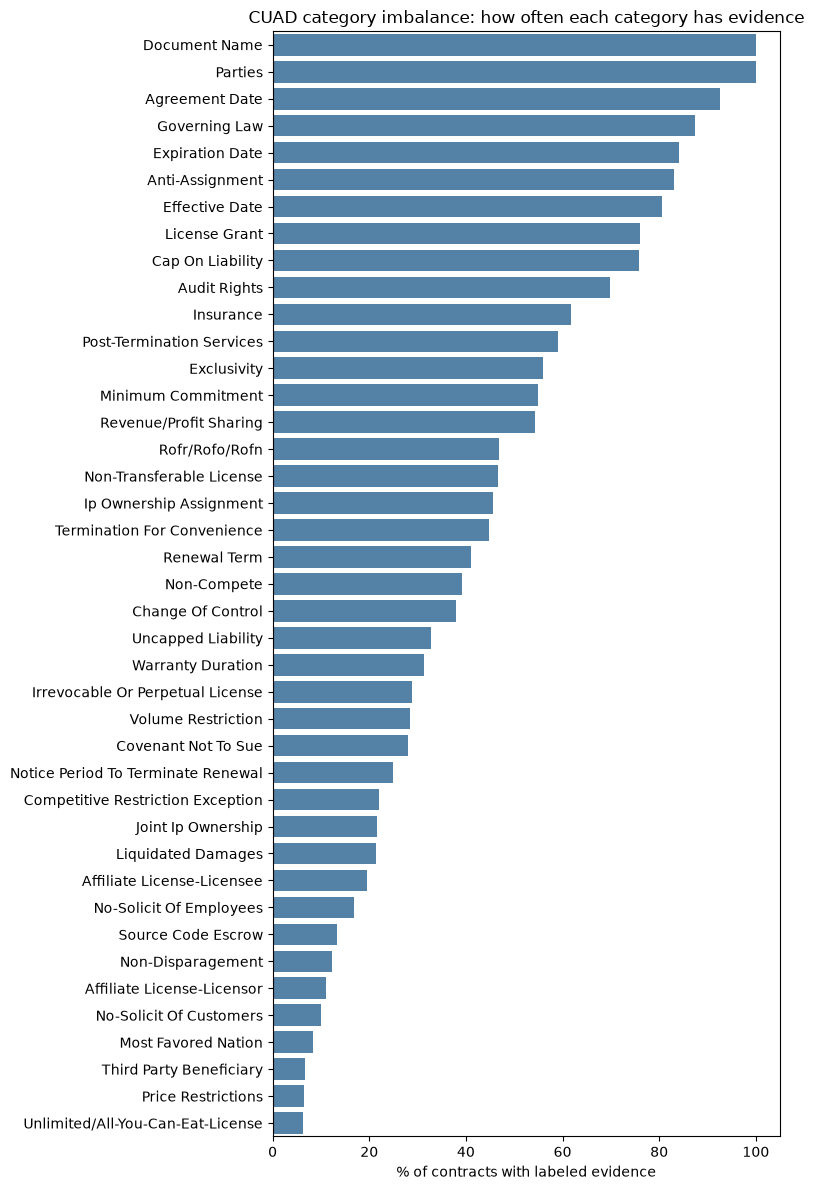

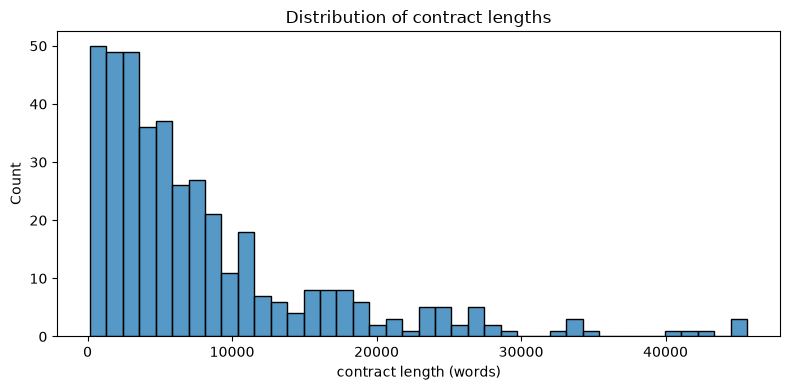

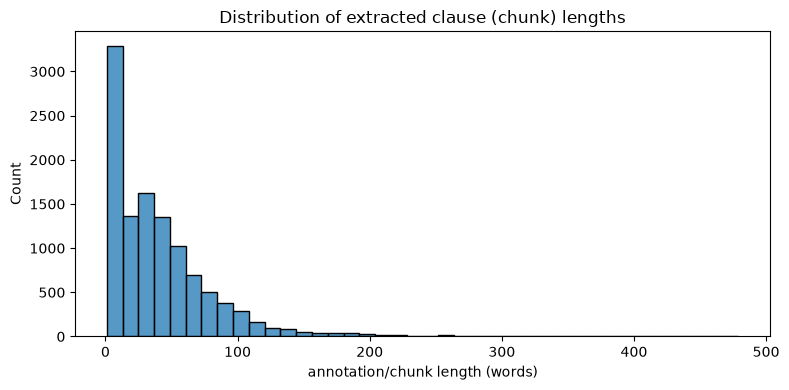

In [14]:
# --- 4. Simple charts ---

# 4a. evidence rate per category (imbalance)
fig, ax = plt.subplots(figsize=(8, 12))
sns.barplot(
    data=category_counts.reset_index(),
    y="category",
    x="pct_with_evidence",
    ax=ax,
    color="steelblue",
)
ax.set_xlabel("% of contracts with labeled evidence")
ax.set_ylabel("")
ax.set_title("CUAD category imbalance: how often each category has evidence")
plt.tight_layout()
plt.show()

# 4b. contract length distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(contract_lengths, bins=40, ax=ax)
ax.set_xlabel("contract length (words)")
ax.set_title("Distribution of contract lengths")
plt.tight_layout()
plt.show()

# 4c. chunk/annotation length distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(chunk_lengths, bins=40, ax=ax)
ax.set_xlabel("annotation/chunk length (words)")
ax.set_title("Distribution of extracted clause (chunk) lengths")
plt.tight_layout()
plt.show()

## Findings

1. **Category evidence rates are extremely imbalanced.** `Document Name` and `Parties` have labeled evidence in 100% of the 408 training contracts, while categories like `Unlimited/All-You-Can-Eat-License` (6.2%), `Price Restrictions` (6.4%), and `Third Party Beneficiary` (6.8%) have evidence in fewer than 1 in 14 contracts. Any per-category classifier trained on this data will need class weighting or resampling for the rare categories.

2. **Overall, 50.2% of all (contract, category) pairs are `is_impossible = True`** (no evidence). The dataset is close to a coin flip between "clause present" and "clause absent" in aggregate, but that balance is entirely driven by averaging — individual categories range from 100% present to 6% present, so the aggregate number hides severe per-category skew.

3. **There's a clear tier structure among categories, not just a single imbalance.** Categories in groups 1 (Dates/Term) and 3 (Control/Assignment) tend to sit at the high end (80-100%), while niche licensing and restriction categories (groups 4/2) cluster below 30%. This suggests the "common" clauses (parties, dates, governing law) are near-universal boilerplate, while the rarer ones are genuinely optional/negotiated terms.

4. **Contract lengths vary enormously and are right-skewed.** Across 408 unique contracts, length ranges from 170 to 45,650 words (mean ~8,038, median ~5,351, std ~8,285). The gap between median and mean, plus the long right tail, means a fixed-length chunking/truncation strategy will need to handle contracts an order of magnitude longer than the median.

5. **Extracted clause (chunk) lengths are short and also right-skewed.** Across 11,180 answered rows, chunk length ranges from 1 to 479 words (mean ~41, median ~31, 75th percentile ~57). Most evidence spans are short phrases or sentences rather than long passages, which matters for how much context a model needs around each span versus how much of the contract it can safely ignore.


# Deeper EDA: multi-span categories, contract breadth, and clause position

In [15]:
# --- 5. Multi-span categories: how many evidence spans per (contract, category)? ---
# clean_df has one row per evidence span, so a category with multiple spans in the
# same contract shows up as multiple rows sharing the same contract_id + category.

spans_per_pair = clean_df.groupby(["contract_id", "category"]).size()
print("distribution of spans per (contract, category) pair:")
print(spans_per_pair.value_counts().sort_index())
print(f"\nmax spans for a single pair: {spans_per_pair.max()}")
print(f"pair with the most spans: {spans_per_pair.idxmax()}")

distribution of spans per (contract, category) pair:
1     14605
2       877
3       387
4       383
5       205
6        73
7        74
8        32
9        18
10       22
11       14
12       11
13        7
14        4
15        4
16        4
18        1
19        2
20        1
22        1
23        1
46        1
55        1
Name: count, dtype: int64

max spans for a single pair: 55
pair with the most spans: ('STARTECGLOBALCOMMUNICATIONSCORP_11_16_1998-EX-10.30-CONSTRUCTION AND MAINTENANCE AGREEMENT', 'Parties')


In [16]:
# --- 6. Contract "breadth": how many distinct categories get evidence per contract? ---
per_contract_evidence = (
    clean_df[~clean_df["is_impossible"]]
    .groupby("contract_id")["category"]
    .nunique()
)
n_zero_evidence_contracts = clean_df["contract_id"].nunique() - per_contract_evidence.shape[0]
print(f"contracts with zero categories having evidence: {n_zero_evidence_contracts}")
print(per_contract_evidence.describe())

# --- 7. Does contract length correlate with how many categories get evidence? ---
# contract_lengths (cell above) keeps its original positional index, not contract_id,
# so rebuild a length series indexed by contract_id here before joining.
contract_lengths_by_id = (
    clean_df.drop_duplicates("contract_id")
    .set_index("contract_id")["text"]
    .str.split()
    .str.len()
)
merged = pd.DataFrame({
    "length_words": contract_lengths_by_id,
    "n_evidenced_categories": per_contract_evidence,
}).fillna(0)
print("\ncorrelation between contract length and number of evidenced categories:")
print(merged.corr())

contracts with zero categories having evidence: 0
count    408.000000
mean      13.377451
std        5.851116
min        2.000000
25%        9.000000
50%       13.000000
75%       18.000000
max       32.000000
Name: category, dtype: float64

correlation between contract length and number of evidenced categories:
                        length_words  n_evidenced_categories
length_words                1.000000                0.598675
n_evidenced_categories      0.598675                1.000000


In [17]:
# --- 8. Where in the document do clauses tend to appear? (relative position) ---
# normalize each evidence span's start offset by its contract's length so
# position is comparable across contracts of very different sizes.

evidenced = clean_df[~clean_df["is_impossible"]].copy()
evidenced["text_len"] = evidenced["text"].str.len()
evidenced["rel_pos"] = evidenced["annotation_start"] / evidenced["text_len"]

print("relative position of evidence spans (0 = start of contract, 1 = end):")
print(evidenced["rel_pos"].describe())

rel_pos_by_category = evidenced.groupby("category")["rel_pos"].median().sort_values()
print("\nearliest-appearing categories (median relative position):")
print(rel_pos_by_category.head(5))
print("\nlatest-appearing categories (median relative position):")
print(rel_pos_by_category.tail(5))

relative position of evidence spans (0 = start of contract, 1 = end):
count    11180.000000
mean         0.385692
std          0.316929
min          0.000000
25%          0.047309
50%          0.358183
75%          0.662909
max          0.999812
Name: rel_pos, dtype: float64

earliest-appearing categories (median relative position):
category
Document Name                        0.002699
Agreement Date                       0.006720
Effective Date                       0.009848
Parties                              0.010386
Competitive Restriction Exception    0.210119
Name: rel_pos, dtype: float64

latest-appearing categories (median relative position):
category
No-Solicit Of Employees    0.692757
Uncapped Liability         0.694986
Third Party Beneficiary    0.759057
Anti-Assignment            0.792311
Governing Law              0.838860
Name: rel_pos, dtype: float64


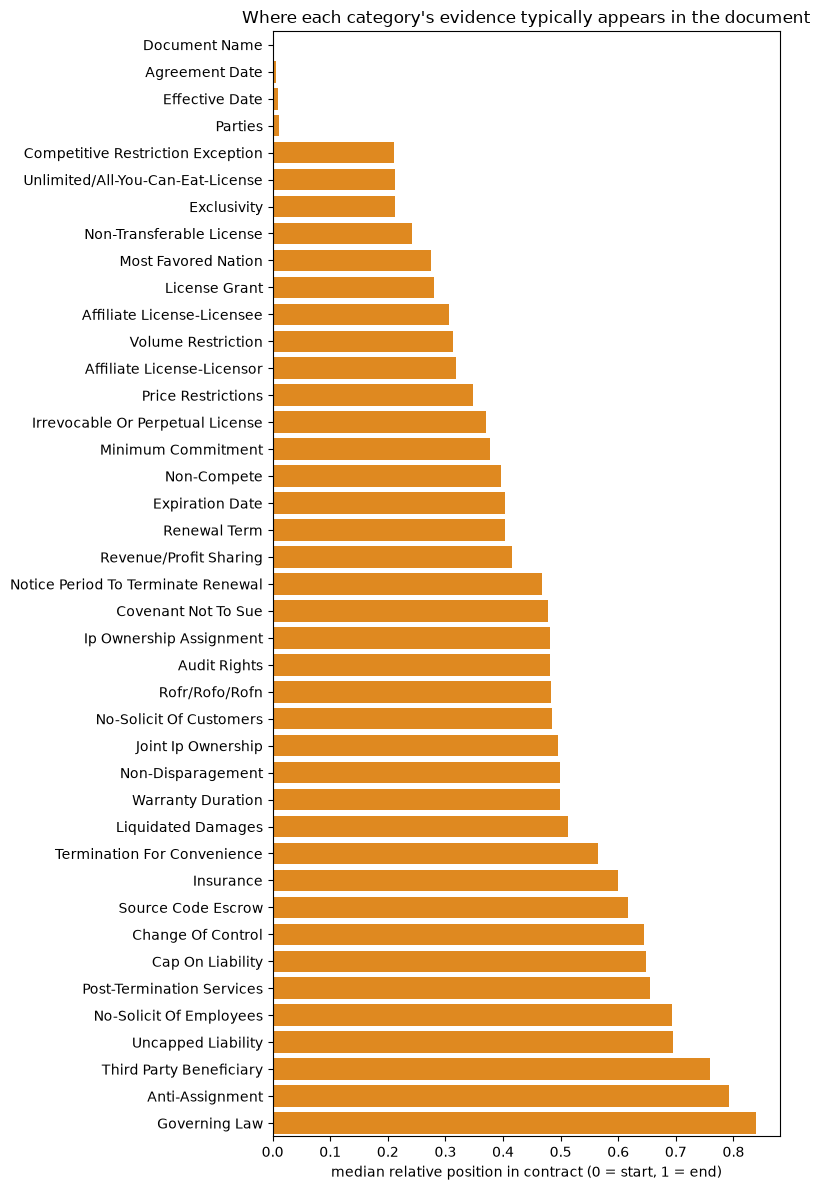

In [18]:
# --- 9. Chart: median relative position per category ---
fig, ax = plt.subplots(figsize=(8, 12))
sns.barplot(
    x=rel_pos_by_category.values,
    y=rel_pos_by_category.index,
    ax=ax,
    color="darkorange",
)
ax.set_xlabel("median relative position in contract (0 = start, 1 = end)")
ax.set_ylabel("")
ax.set_title("Where each category's evidence typically appears in the document")
plt.tight_layout()
plt.show()

## Additional findings

6. **Multi-span categories are common, and a few pairs are extreme outliers.** Most (contract, category) pairs have exactly one evidence span, but hundreds have 2+, tailing off up to a single (contract, category) pair with **55 separate spans** (`Parties` in a construction/maintenance agreement). Any downstream step that treats a (contract, category) pair as having one canonical answer needs an explicit rule for collapsing multiple spans (e.g. concatenate, take longest, or keep all).

7. **Every contract has at least some evidenced categories, but "breadth" varies widely.** Across the 408 contracts, the number of distinct categories with evidence ranges from 2 to 32 (out of 41 possible), with a median of 13. No contract has zero evidenced categories, so the annotation coverage is consistent, but some contracts are far more thoroughly represented than others.

8. **Contract length correlates with how many categories get evidence (r ≈ 0.60).** Longer contracts don't just have more words — they tend to contain more distinct clause types. Document length is therefore a usable proxy signal for how much there is to extract, and short contracts are systematically evidence-sparse rather than just being harder to search.

9. **Clause position in the document is strongly category-dependent.** Normalizing each evidence span's start offset by contract length shows that `Document Name`, `Agreement Date`, `Effective Date`, and `Parties` almost always appear in the first ~1% of the document (the preamble), while `Governing Law`, `Anti-Assignment`, and `Third Party Beneficiary` cluster near the end (median relative position 0.76-0.84) as standard "boilerplate" miscellaneous clauses. A retrieval or chunking strategy under a context-length budget could exploit this instead of scanning the whole document uniformly for every category.


# More EDA: category groups, chunk length by category, co-occurrence

In [19]:
# --- 10. Evidence rate by CUAD's organizational "Group" (dates, licensing, liability, etc.) ---
# category_descriptions.csv casing doesn't match clean_df's category casing
# (e.g. "Cap on Liability" vs "Cap On Liability"), so join on a lowercased key.

cat_desc = pd.read_csv(Path(target_path).parent / "category_descriptions.csv")
cat_desc.columns = [c.strip() for c in cat_desc.columns]
cat_desc["category"] = cat_desc["Category (incl. context and answer)"].str.replace("Category: ", "", regex=False)
cat_desc["group"] = cat_desc["Group"].str.replace("Group: ", "", regex=False)
cat_desc["category_key"] = cat_desc["category"].str.lower()

category_counts_with_group = category_counts.reset_index()
category_counts_with_group["category_key"] = category_counts_with_group["category"].str.lower()
category_counts_with_group = category_counts_with_group.merge(
    cat_desc[["category_key", "group"]], on="category_key", how="left"
)

group_evidence_rate = (
    category_counts_with_group.groupby("group")["pct_with_evidence"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print("mean evidence rate by category group ('-' = ungrouped):")
print(group_evidence_rate)

mean evidence rate by category group ('-' = ungrouped):
            mean  count
group                  
1      64.580000      5
5      64.500000      2
3      60.450000      2
6      54.300000      2
-      39.525000     20
2      31.800000      4
4      31.383333      6


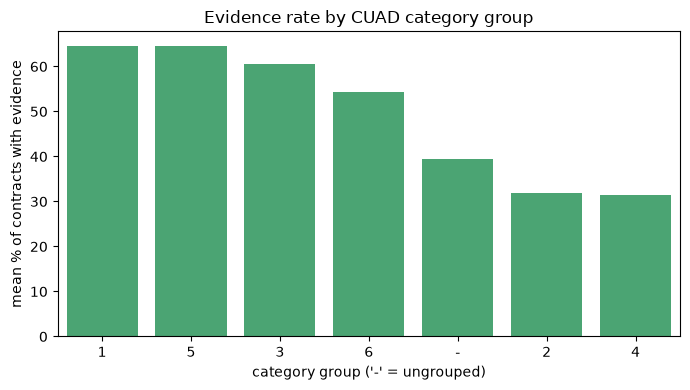

In [20]:
# --- 11. Chart: mean evidence rate by group ---
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=group_evidence_rate.index.astype(str),
    y=group_evidence_rate["mean"],
    ax=ax,
    color="mediumseagreen",
)
ax.set_xlabel("category group ('-' = ungrouped)")
ax.set_ylabel("mean % of contracts with evidence")
ax.set_title("Evidence rate by CUAD category group")
plt.tight_layout()
plt.show()

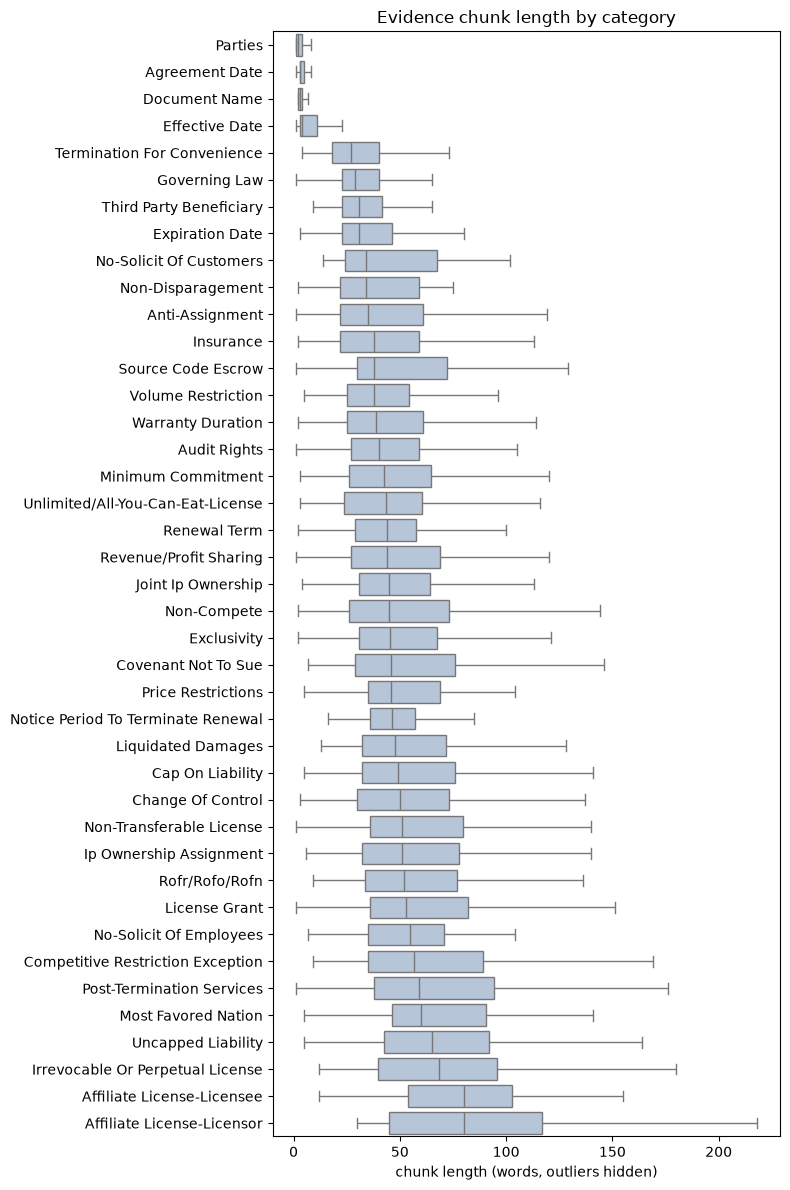

In [21]:
# --- 12. Chunk length by category (boxplot, sorted by median) ---
evidenced["chunk_words"] = evidenced["annotation_text"].str.split().str.len()
order = evidenced.groupby("category")["chunk_words"].median().sort_values().index

fig, ax = plt.subplots(figsize=(8, 12))
sns.boxplot(
    data=evidenced,
    y="category",
    x="chunk_words",
    order=order,
    showfliers=False,
    color="lightsteelblue",
    ax=ax,
)
ax.set_xlabel("chunk length (words, outliers hidden)")
ax.set_ylabel("")
ax.set_title("Evidence chunk length by category")
plt.tight_layout()
plt.show()

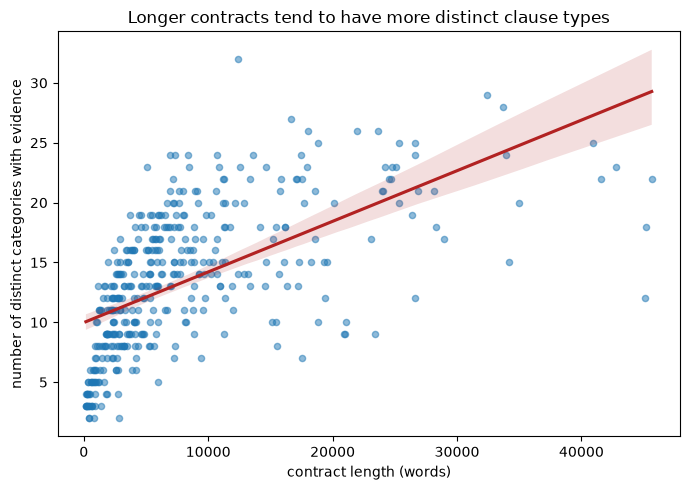

In [22]:
# --- 13. Chart: contract length vs number of evidenced categories (visualizes the r ~ 0.6 correlation) ---
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=merged,
    x="length_words",
    y="n_evidenced_categories",
    scatter_kws={"alpha": 0.5, "s": 20},
    line_kws={"color": "firebrick"},
    ax=ax,
)
ax.set_xlabel("contract length (words)")
ax.set_ylabel("number of distinct categories with evidence")
ax.set_title("Longer contracts tend to have more distinct clause types")
plt.tight_layout()
plt.show()

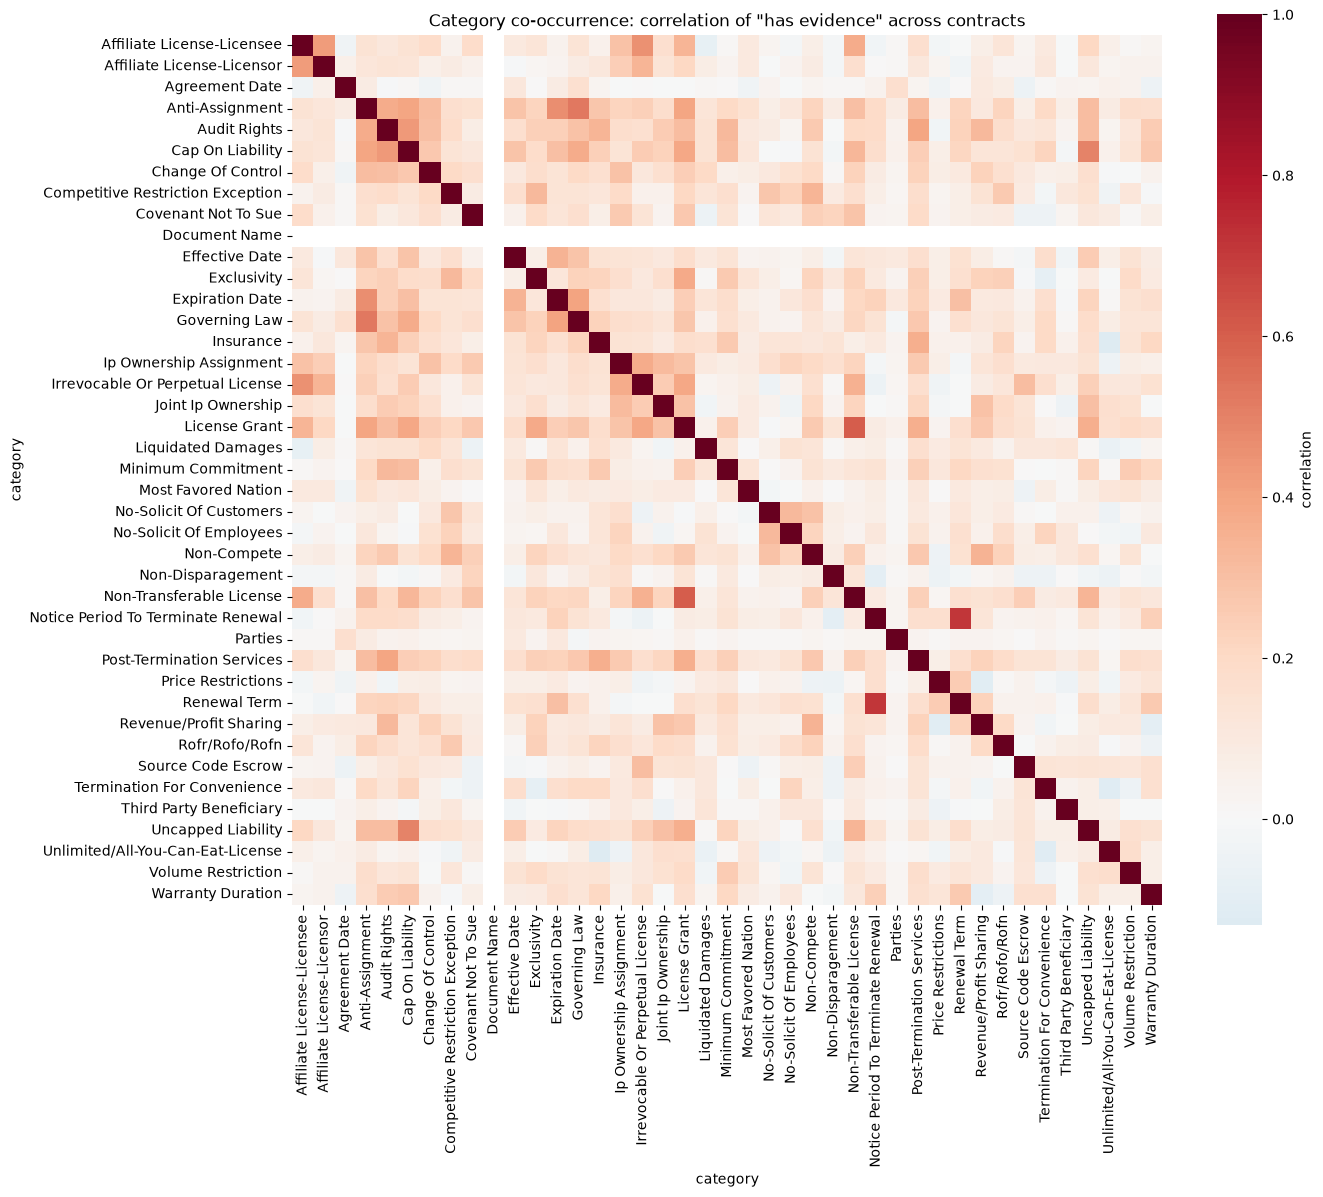

most positively correlated category pairs:
category                            category                
Notice Period To Terminate Renewal  Renewal Term                0.710499
License Grant                       Non-Transferable License    0.605470
Anti-Assignment                     Governing Law               0.527298
Cap On Liability                    Uncapped Liability          0.492167
Anti-Assignment                     Expiration Date             0.467127
dtype: float64


In [23]:
# --- 14. Category co-occurrence: do contracts that have one category tend to have another? ---
# build a (contract x category) boolean matrix of "has evidence", then correlate columns.

has_evidence_matrix = (
    clean_df.drop_duplicates(["contract_id", "category"])
    .pivot(index="contract_id", columns="category", values="is_impossible")
    .pipe(lambda d: ~d.fillna(True))  # missing pair = no evidence recorded = False
)
category_corr = has_evidence_matrix.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(category_corr, cmap="RdBu_r", center=0, square=True, ax=ax, cbar_kws={"label": "correlation"})
ax.set_title("Category co-occurrence: correlation of \"has evidence\" across contracts")
plt.tight_layout()
plt.show()

# most correlated (non-self) category pairs
corr_pairs = category_corr.where(np.triu(np.ones(category_corr.shape), k=1).astype(bool)).stack()
print("most positively correlated category pairs:")
print(corr_pairs.sort_values(ascending=False).head(5))

## More findings

10. **CUAD's "Group" metadata predicts evidence rate.** Grouped categories average much higher evidence rates than ungrouped ones: group 1 (Dates/Term, 64.6%) and group 5 (Post-termination/Audit, 64.5%) sit well above the 20 ungrouped categories (39.5%), and group 4 (Licensing, 31.4%) and group 2 (Competitive restrictions, 31.8%) sit even lower. CUAD's organizational grouping isn't just a label — it tracks how often that theme of clause actually shows up in a contract.

11. **Chunk length differs meaningfully by category, not just overall.** Short, canonical answers (`Parties`, `Agreement Date`, `Document Name` — median 2-3 words) sit at one end, while narrative categories like `Affiliate License-Licensee/-Licensor` and `Irrevocable or Perpetual License` (median 68-80 words) sit at the other. A single fixed span-length assumption for extraction would be wrong for most categories in one direction or the other.

12. **Categories co-occur in logically related pairs.** The strongest correlation in the co-occurrence heatmap is `Notice Period to Terminate Renewal` with `Renewal Term` (r = 0.71) — contracts with a renewal term almost always also specify how to terminate it. Other strong pairs make similar sense: `License Grant` with `Non-Transferable License` (0.61), `Anti-Assignment` with `Governing Law` (0.53), and `Cap on Liability` with `Uncapped Liability` (0.49, likely mutually-referencing/contrasting clauses). This means category presence isn't independent — a model (or a human reviewer) that finds one of a correlated pair should specifically check for its partner.


## Summary: the most important EDA points

- **This is a fundamentally imbalanced, multi-label dataset, not a single balanced classification problem.** Evidence rate per category ranges from 100% (`Document Name`, `Parties`) down to ~6% (`Unlimited/All-You-Can-Eat-License`, `Price Restrictions`), so per-category models will need class weighting or resampling, and the 50.2% overall `is_impossible` rate hides that huge per-category spread rather than describing a real 50/50 split.

- **Categories cluster into a "near-universal boilerplate" tier and a "rare/negotiated" tier**, and this splits along CUAD's own Group metadata: Dates/Term and Post-termination/Audit groups average ~65% evidence, while Licensing and Competitive-restriction groups average ~31-32%. Grouping isn't just organizational — it's predictive.

- **Contracts vary enormously in size (170 to 45,650 words) and richness (2 to 32 of 41 categories evidenced per contract), and the two are correlated (r ≈ 0.6).** Longer contracts systematically contain more distinct clause types, not just more boilerplate text — any chunking/truncation strategy needs to handle that range, not just the median.

- **Where a clause appears in the document is highly predictable by category.** Preamble categories (`Document Name`, `Parties`, `Agreement Date`, `Effective Date`) sit in the first ~1% of the text; "miscellaneous" categories (`Governing Law`, `Anti-Assignment`, `Third Party Beneficiary`) cluster in the last ~20-25%. This positional signal could cut down search space for retrieval/chunking instead of scanning full documents uniformly.

- **Evidence spans (chunks) are short overall (median 31 words) but vary a lot by category** — from 2-3 word canonical answers (`Parties`, dates) to 60-80 word narrative clauses (affiliate licensing, perpetual license terms) — so a single fixed span-length assumption doesn't fit all categories.

- **Categories are not independent of each other.** The strongest co-occurrence is `Notice Period to Terminate Renewal` with `Renewal Term` (r = 0.71); several other logically-paired categories (licensing terms, liability caps) also co-occur strongly. This means clause presence carries information about other clauses in the same contract.

- **The preprocessing pipeline checks out clean**: 0 mismatches in the independent re-clean integrity check (11,180/11,180 answered rows verified), 0 duplicate ids, 0 rows with contradictory `is_impossible`/`annotation_text` state, and every contract has at least 2 evidenced categories (no silently-empty contracts). The imbalance and variability found above are properties of the CUAD dataset itself, not artifacts of a broken pipeline.
